In [1]:
# Phase 1: Environmental Configuration & Hyperparameters
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, cohen_kappa_score, matthews_corrcoef)
# --- CONFIGURATION ---
PARAMS = {
    "VOCAB_SIZE": 3000,
    "HIDDEN_DIM": 64,
    "EPOCHS": 100,
    "LR": 1e-3,
    "SEED": 42
}
torch.manual_seed(PARAMS["SEED"])
np.random.seed(PARAMS["SEED"])

In [2]:
# Phase 2: Data Engineering (IMDB Adaptation)
# --- DATA LOADING ---
# Load IMDB dataset: Col 1: review, Col 2: sentiment
df = pd.read_csv('imdb.csv') 
df = df[['review', 'sentiment']] # Ensure correct column order

# Encoding: positive -> 1, negative -> 0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=PARAMS["VOCAB_SIZE"], stop_words='english')
X = tfidf.fit_transform(df['review']).toarray()
y = df['sentiment'].values

# Split: 70% Train, 15% Val, 15% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=PARAMS["SEED"])
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1764, random_state=PARAMS["SEED"])

# Convert to PyTorch Tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)
X_test_t = torch.FloatTensor(X_test)

In [3]:
# Phase 3 & 4: Architectures & Loss Functions
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

class MLPModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, PARAMS["HIDDEN_DIM"]),
            nn.ReLU(),
            nn.Linear(PARAMS["HIDDEN_DIM"], 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

loss_functions = {
    "BCE": nn.BCELoss(),
    "MSE": nn.MSELoss(),
    "MAE": nn.L1Loss(),
    "Huber": nn.SmoothL1Loss(),
    "Margin": nn.SoftMarginLoss()
}

In [4]:
# Phase 5 & 6: Training Loop & Multi-Metric Evaluation
results_history = {}
performance_metrics = []

for model_type in ["LR", "MLP"]:
    for loss_name, criterion in loss_functions.items():
        exp_name = f"{model_type}_{loss_name}"
        print(f"Executing: {exp_name} on IMDB Dataset...")
        
        model = LogisticRegressionModel(PARAMS["VOCAB_SIZE"]) if model_type == "LR" else MLPModel(PARAMS["VOCAB_SIZE"])
        optimizer = optim.Adam(model.parameters(), lr=PARAMS["LR"])
        
        train_accs, val_accs = [], []
        
        for epoch in range(PARAMS["EPOCHS"]):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train_t)
            
            if isinstance(criterion, nn.SoftMarginLoss):
                loss = criterion(outputs, y_train_t.clone().apply_(lambda x: 1 if x == 1 else -1))
            else:
                loss = criterion(outputs, y_train_t)
                
            loss.backward()
            optimizer.step()
            
            # Validation Tracking
            model.eval()
            with torch.no_grad():
                v_pred = (model(X_val_t) > 0.5).float().numpy()
                t_pred = (model(X_train_t) > 0.5).float().numpy()
                train_accs.append(accuracy_score(y_train, t_pred))
                val_accs.append(accuracy_score(y_val, v_pred))
        
        results_history[exp_name] = {"train": train_accs, "val": val_accs}
        
        # Test Metrics
        with torch.no_grad():
            y_pred_test = (model(X_test_t) > 0.5).float().numpy()
            performance_metrics.append({
                "Model_Loss": exp_name,
                "Accuracy": accuracy_score(y_test, y_pred_test),
                "Precision": precision_score(y_test, y_pred_test, zero_division=0),
                "Recall": recall_score(y_test, y_pred_test, zero_division=0),
                "F1-Score": f1_score(y_test, y_pred_test, zero_division=0),
                "MCC": matthews_corrcoef(y_test, y_pred_test),
                "Kappa": cohen_kappa_score(y_test, y_pred_test)
            })

Executing: LR_BCE on IMDB Dataset...
Executing: LR_MSE on IMDB Dataset...
Executing: LR_MAE on IMDB Dataset...
Executing: LR_Huber on IMDB Dataset...
Executing: LR_Margin on IMDB Dataset...
Executing: MLP_BCE on IMDB Dataset...
Executing: MLP_MSE on IMDB Dataset...
Executing: MLP_MAE on IMDB Dataset...
Executing: MLP_Huber on IMDB Dataset...
Executing: MLP_Margin on IMDB Dataset...


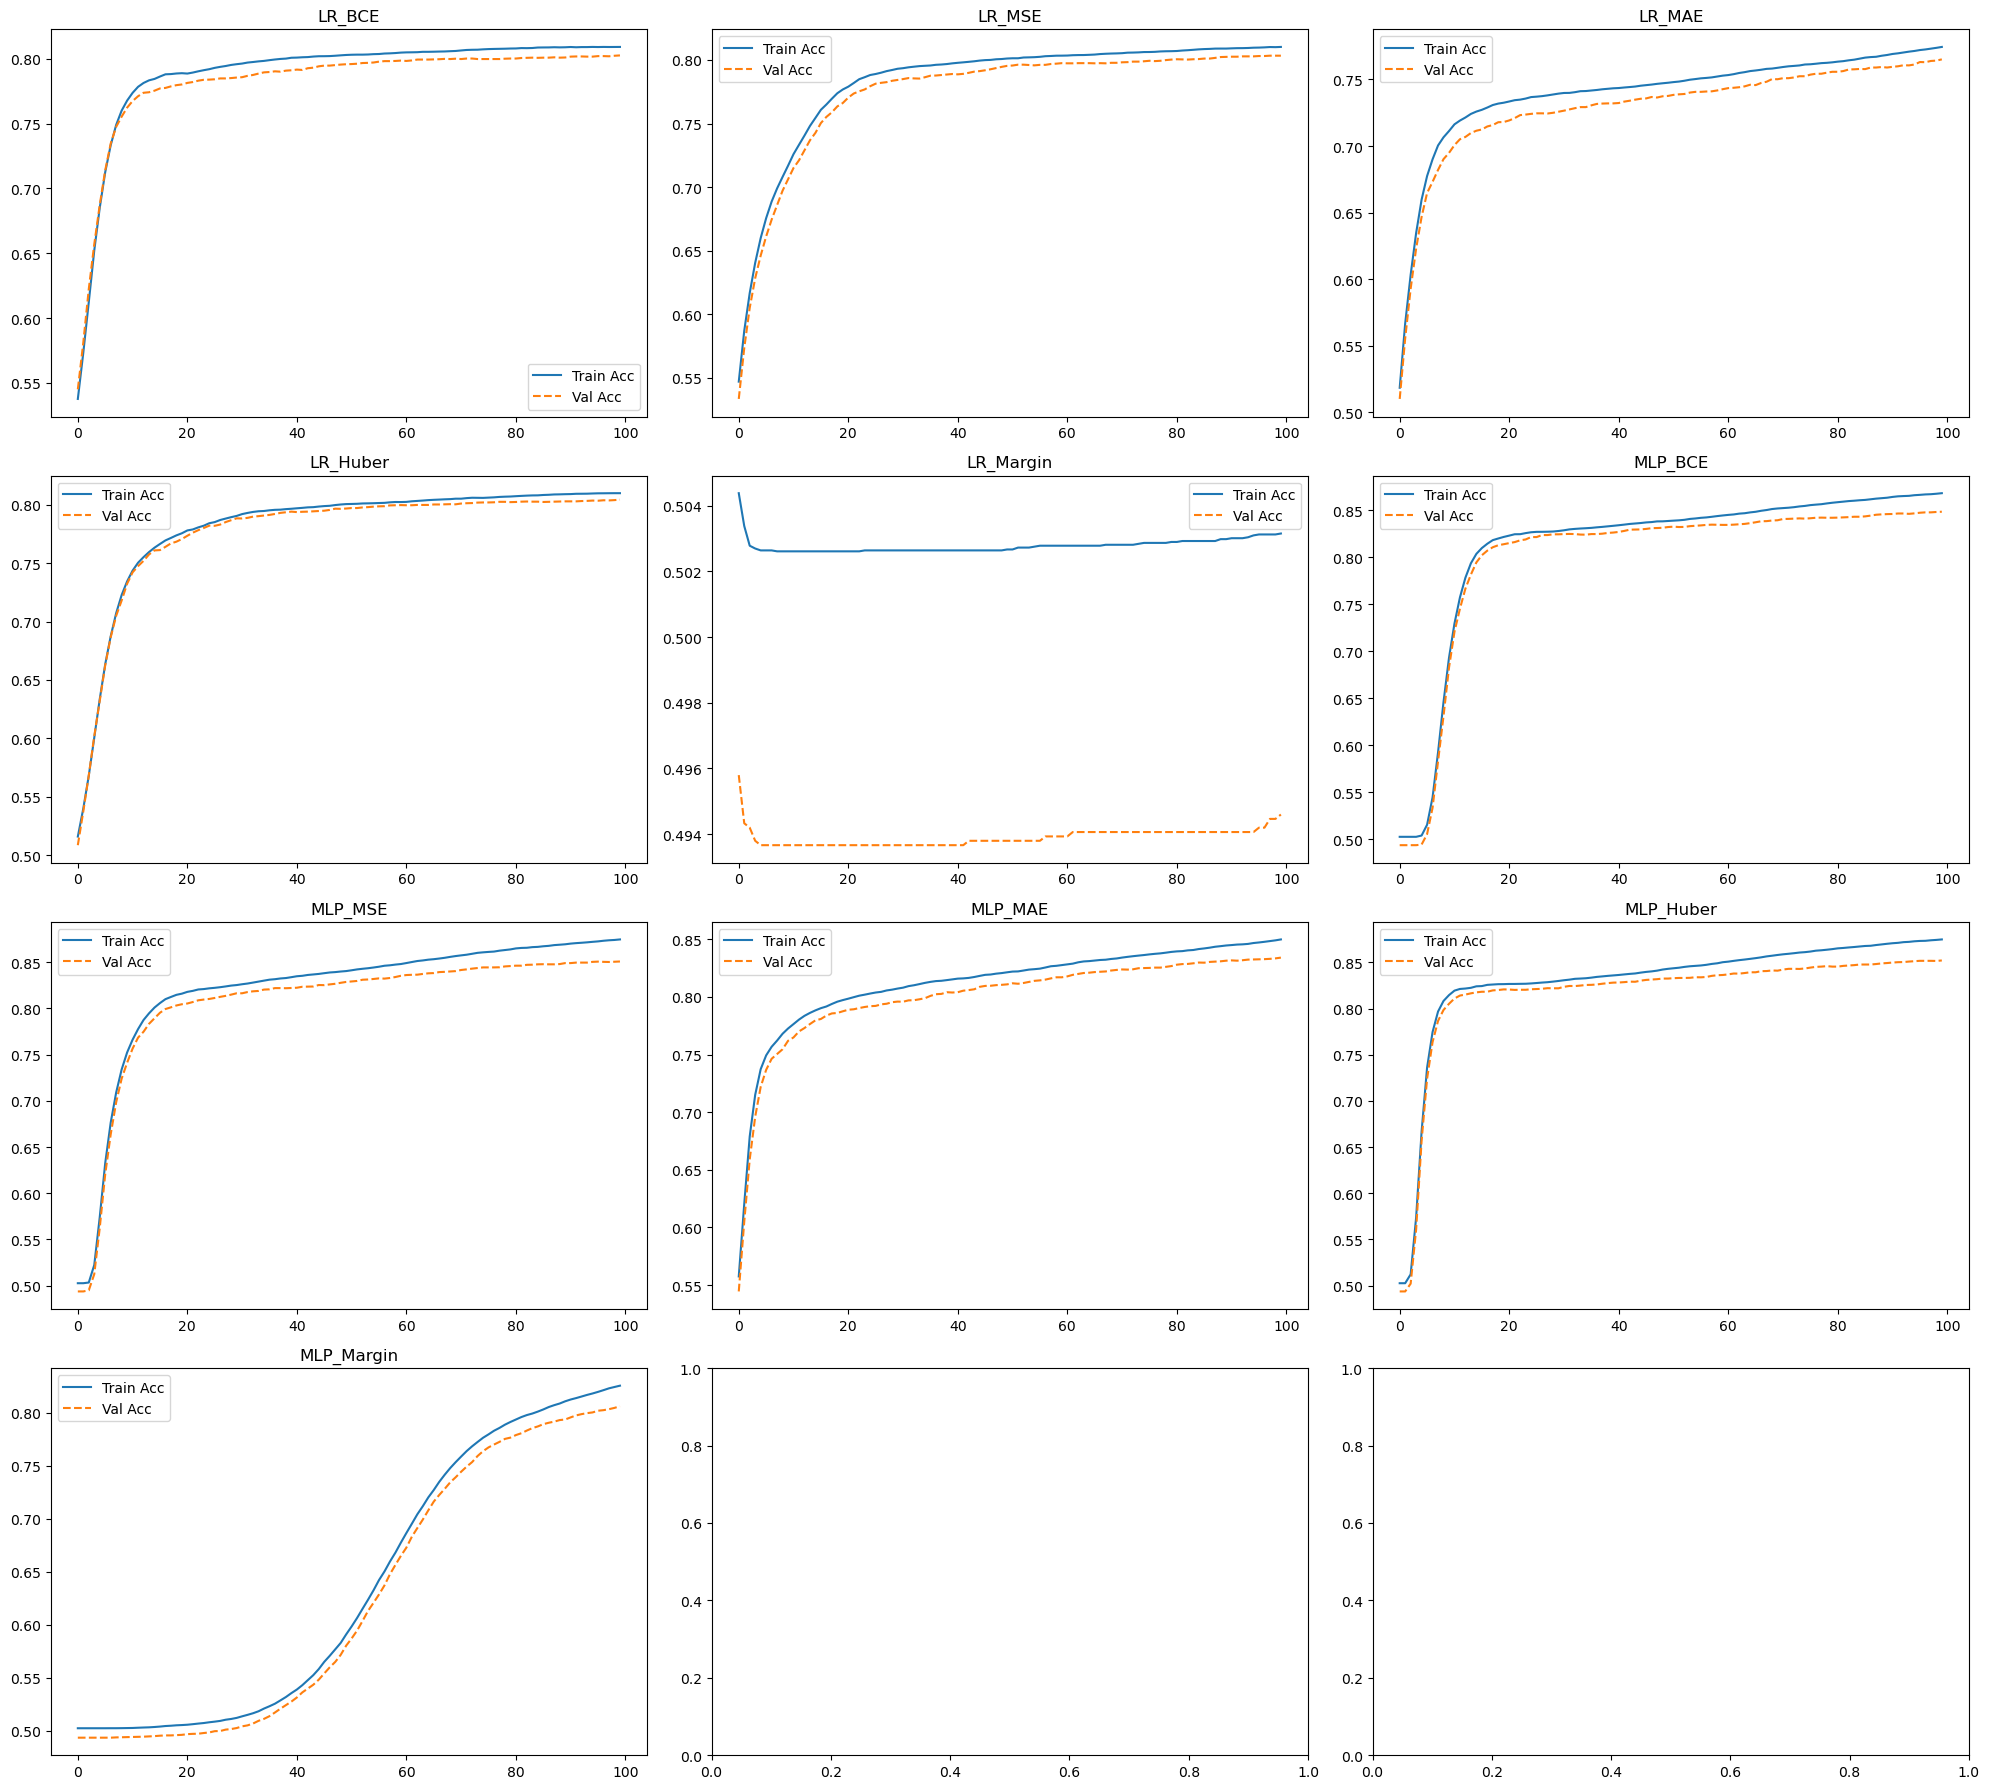

In [5]:
# Phase 7: Visualization and Final Report
# Visualization of Learning Curves
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.ravel()
for i, (name, h) in enumerate(results_history.items()):
    axes[i].plot(h["train"], label='Train Acc')
    axes[i].plot(h["val"], label='Val Acc', linestyle='--')
    axes[i].set_title(name)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [6]:
# Final Comparison Table
print("\n" + "="*100)
print("IMDB DATASET")
print("="*100)
report_df = pd.DataFrame(performance_metrics)
print(report_df.to_string(index=False))


IMDB DATASET
Model_Loss  Accuracy  Precision   Recall  F1-Score      MCC    Kappa
    LR_BCE  0.807467   0.815761 0.799842  0.807723 0.615090 0.614970
    LR_MSE  0.806933   0.813873 0.801424  0.807600 0.613959 0.613885
    LR_MAE  0.770133   0.869022 0.642141  0.738550 0.561366 0.541565
  LR_Huber  0.807067   0.812583 0.803797  0.808167 0.614169 0.614132
 LR_Margin  0.495067   1.000000 0.001319  0.002634 0.025541 0.001304
   MLP_BCE  0.850933   0.851287 0.854430  0.852856 0.701822 0.701817
   MLP_MSE  0.852933   0.855406 0.853376  0.854389 0.705840 0.705838
   MLP_MAE  0.835333   0.837781 0.836234  0.837007 0.670633 0.670632
 MLP_Huber  0.853867   0.855111 0.856013  0.855561 0.707694 0.707693
MLP_Margin  0.809067   0.910578 0.690137  0.785179 0.638453 0.619130
